<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/March2026/28MarchConvNeXt_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install cleanlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 11.9 MB/s eta 0:00:00


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader, Subset
import numpy as np
from cleanlab.filter import find_label_issues

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train_dir = "/content/drive/MyDrive/ResearchData/March26/DatasetTrainVsTestCropped1128/train"
val_dir =   "/content/drive/MyDrive/ResearchData/March26/DatasetTrainVsTestCropped1128/val"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(train_dir))

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.convnext_base(pretrained=True)

# Replace classifier
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 130MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [9]:
EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f}")

    scheduler.step()



Epoch 1/20
Train Loss: 1.2085 | Val Loss: 1.0355 | Acc: 0.5539
Epoch 2/20
Train Loss: 0.7983 | Val Loss: 0.8029 | Acc: 0.6707
Epoch 3/20
Train Loss: 0.5516 | Val Loss: 0.8579 | Acc: 0.6766
Epoch 4/20
Train Loss: 0.3694 | Val Loss: 0.7790 | Acc: 0.6976
Epoch 5/20
Train Loss: 0.2365 | Val Loss: 0.9566 | Acc: 0.6647
Epoch 6/20
Train Loss: 0.1292 | Val Loss: 0.8613 | Acc: 0.7186
Epoch 7/20
Train Loss: 0.0637 | Val Loss: 0.9598 | Acc: 0.7156
Epoch 8/20
Train Loss: 0.0711 | Val Loss: 1.0482 | Acc: 0.7156
Epoch 9/20
Train Loss: 0.0756 | Val Loss: 1.1301 | Acc: 0.6826
Epoch 10/20
Train Loss: 0.0370 | Val Loss: 1.0716 | Acc: 0.7066
Epoch 11/20
Train Loss: 0.0331 | Val Loss: 1.0723 | Acc: 0.7006
Epoch 12/20
Train Loss: 0.0210 | Val Loss: 1.0411 | Acc: 0.7096
Epoch 13/20
Train Loss: 0.0109 | Val Loss: 1.0732 | Acc: 0.7186
Epoch 14/20
Train Loss: 0.0103 | Val Loss: 1.0855 | Acc: 0.7036
Epoch 15/20
Train Loss: 0.0106 | Val Loss: 1.0823 | Acc: 0.7066
Epoch 16/20
Train Loss: 0.0071 | Val Loss: 1.0821

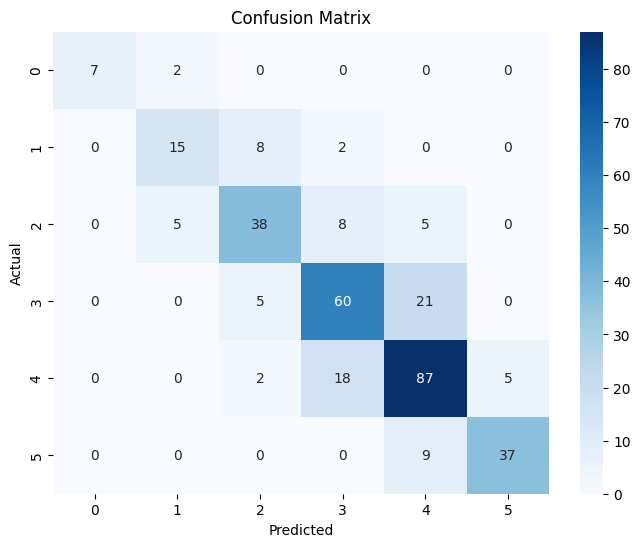

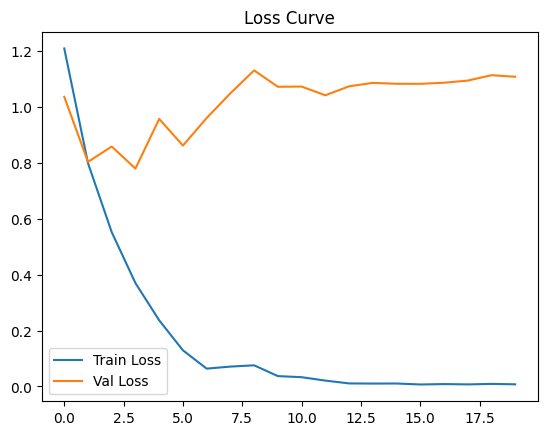

In [11]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
torch.save(model.state_dict(), "convnext_model.pth")
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [12]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False):
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# Convert to numpy
pred_probs = np.concatenate(all_probs)
labels = np.concatenate(all_labels)

In [13]:
issue_indices = find_label_issues(
    labels=labels,
    pred_probs=pred_probs
)

print(f"Found {len(issue_indices)} suspicious samples")

Found 778 suspicious samples


In [14]:
clean_indices = list(set(range(len(train_dataset))) - set(issue_indices))

clean_dataset = Subset(train_dataset, clean_indices)

clean_loader = DataLoader(clean_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
# Reinitialize model
model = models.convnext_base(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

train_model(model, clean_loader, epochs=10)

NameError: name 'train_model' is not defined

In [17]:
from sklearn.metrics import accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
print("Final Accuracy:", acc)

KeyboardInterrupt: 

In [ ]:
corrected_labels = np.argmax(pred_probs, axis=1)

# Replace only suspicious labels
for idx in issue_indices:
    train_dataset.targets[idx] = corrected_labels[idx]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# show top-k suspicious samples
def show_label_issues(dataset, issue_indices, class_names, num_images=12):
    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(issue_indices[:num_images]):
        img, label = dataset[idx]

        img = img.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {class_names[label]}")
        plt.axis("off")

    plt.suptitle("Suspicious / Mislabeled Samples", fontsize=16)
    plt.show()


# call it
show_label_issues(train_dataset, issue_indices, train_dataset.classes)

In [ ]:
def show_with_predictions(dataset, issue_indices, model, class_names):
    model.eval()
    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(issue_indices[:12]):
        img, label = dataset[idx]
        input_img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_img)
            pred = torch.argmax(output, 1).item()

        img = img.permute(1, 2, 0).numpy()

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"T:{class_names[label]}\nP:{class_names[pred]}")
        plt.axis("off")

    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
def get_top_confusions(cm, class_names, top_k=5):
    confusions = []

    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j:
                confusions.append((cm[i][j], class_names[i], class_names[j]))

    confusions.sort(reverse=True)

    print("\nTop Confusions:")
    for c in confusions[:top_k]:
        print(f"{c[1]} → {c[2]} : {c[0]}")

In [ ]:
def get_pseudo_labels(model, dataset, threshold=0.9):
    model.eval()

    pseudo_data = []

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            max_probs, preds = torch.max(probs, dim=1)

            for i in range(len(images)):
                if max_probs[i] > threshold:
                    pseudo_data.append((images[i].cpu(), preds[i].cpu()))

    return pseudo_data

In [ ]:
from torch.utils.data import Dataset

class PseudoDataset(Dataset):
    def __init__(self, pseudo_data):
        self.data = pseudo_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [ ]:
train_model(model, combined_loader, epochs=5)